In [0]:
# Import required libraries
from pyspark.sql.functions import to_date, months_between, col, current_date
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# Load Data
df = spark.table("data_processed.credit_risk_main.loans_featureengineered")

Calculate default rates by interest rate and grade

In [0]:
# Create interest rate bins

from pyspark.sql import functions as F

df = (
    df.withColumn(
        "int_rate_bin",
        F.when(F.col("int_rate") < 10, "Low (<10%)")
         .when((F.col("int_rate") >= 10) & (F.col("int_rate") < 15), "Medium (10–15%)")
         .otherwise("High (15%+)")
    )
)

In [0]:
# Group by bins and grade, calculate default rate
default_summary = (
    df.groupBy("int_rate_bin", "grade")
      .agg(F.round(F.avg("default_ind") * 100, 2).alias("default_rate_pct"))
      .orderBy("int_rate_bin", "grade")
)

In [0]:
display(default_summary)

int_rate_bin,grade,default_rate_pct
High (15%+),C,13.53
High (15%+),D,8.01
High (15%+),E,9.71
High (15%+),F,14.13
High (15%+),G,16.7
Low (<10%),A,1.83
Low (<10%),B,1.22
Low (<10%),C,0.0
Low (<10%),D,0.0
Low (<10%),E,5.26


Databricks visualization. Run in Databricks to view.

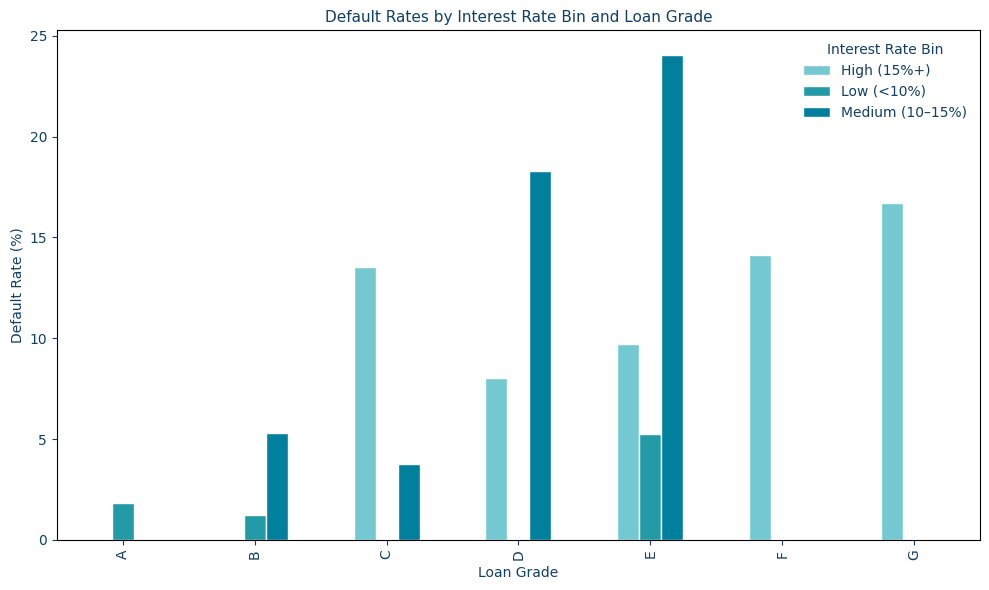

In [0]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame → Pandas
pd_default_summary = default_summary.toPandas()

# Pivot for grouped bar chart
pivot_df = pd_default_summary.pivot(
    index="grade", columns="int_rate_bin", values="default_rate_pct"
)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10,6))

# Set custom background colors
fig.patch.set_facecolor("white")   # overall figure background
ax.set_facecolor("white")          # chart area background

# Plot bars with light shades
pivot_df.plot(
    kind="bar",
    ax=ax,
    color=["#73C8D2", "#239BA7", "#00809D"],  # lightblue, lightgreen, lightsalmon
    edgecolor="white"
)

# Titles and labels with white text
ax.set_title("Default Rates by Interest Rate Bin and Loan Grade", fontsize=11, color="#113F67")
ax.set_ylabel("Default Rate (%)", color="#113F67")
ax.set_xlabel("Loan Grade", color="#113F67")

# White ticks
ax.tick_params(axis="x", colors="#113F67")
ax.tick_params(axis="y", colors="#113F67")

# Legend with dark background
legend = ax.legend(title="Interest Rate Bin", facecolor="white", edgecolor="white")
plt.setp(legend.get_texts(), color="#113F67")
plt.setp(legend.get_title(), color="#113F67")

plt.tight_layout()
plt.show()



High DTI and revolving utilization are strong predictors of default.

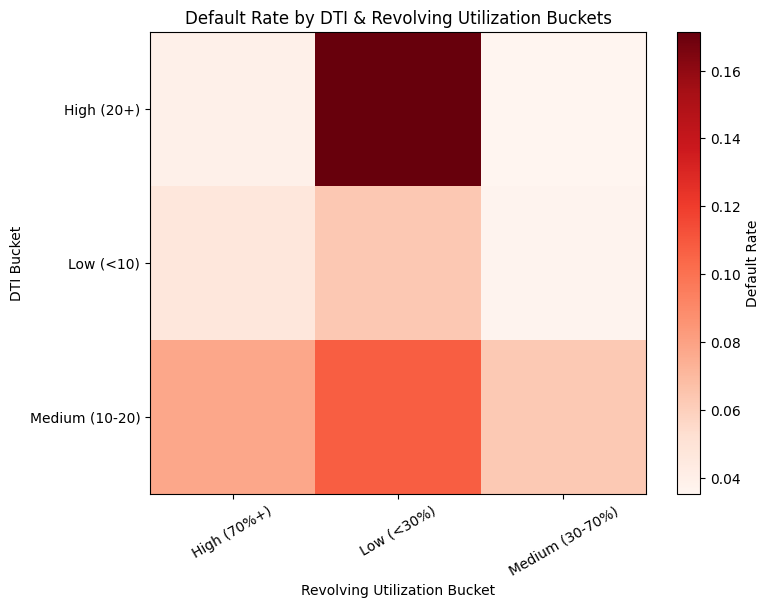

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Bucketize DTI and Revolving Utilization into risk groups
df_buckets = (
    df.withColumn(
        "DTI_bucket",
        F.when(F.col("debt_to_income_ratio") < 10, "Low (<10)")
         .when((F.col("debt_to_income_ratio") >= 10) & (F.col("debt_to_income_ratio") < 20), "Medium (10-20)")
         .otherwise("High (20+)")
    )
    .withColumn(
        "RevolUtil_bucket",
        F.when(F.col("revol_utilization") < 30, "Low (<30%)")
         .when((F.col("revol_utilization") >= 30) & (F.col("revol_utilization") < 70), "Medium (30-70%)")
         .otherwise("High (70%+)")
    )
)

# Step 2: Calculate default rate per group
default_summary = (
    df_buckets.groupBy("DTI_bucket", "RevolUtil_bucket")
    .agg(F.mean("default_ind").alias("default_rate"),
         F.count("*").alias("count"))
)

# Convert to Pandas for plotting
default_pdf = default_summary.toPandas()

# Step 3: Pivot for heatmap-like plotting
pivot_df = default_pdf.pivot(index="DTI_bucket", columns="RevolUtil_bucket", values="default_rate")

# Plot heatmap-style
plt.figure(figsize=(8,6))
plt.imshow(pivot_df, cmap="Reds", aspect="auto")
plt.colorbar(label="Default Rate")
plt.xticks(range(len(pivot_df.columns)), pivot_df.columns, rotation=30)
plt.yticks(range(len(pivot_df.index)), pivot_df.index)
plt.title("Default Rate by DTI & Revolving Utilization Buckets")
plt.xlabel("Revolving Utilization Bucket")
plt.ylabel("DTI Bucket")
plt.show()


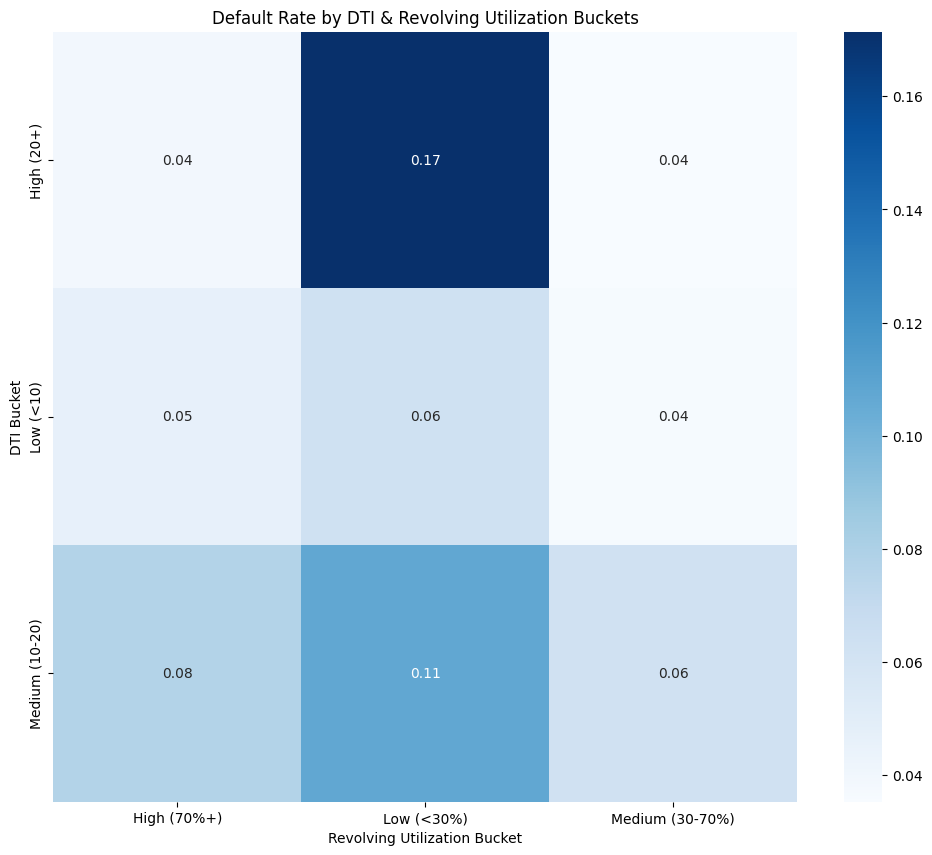

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Bucketize DTI and Revolving Utilization
df_buckets = (
    df.withColumn(
        "DTI_bucket",
        F.when(F.col("debt_to_income_ratio") < 10, "Low (<10)")
         .when((F.col("debt_to_income_ratio") >= 10) & (F.col("debt_to_income_ratio") < 20), "Medium (10-20)")
         .otherwise("High (20+)")
    )
    .withColumn(
        "RevolUtil_bucket",
        F.when(F.col("revol_utilization") < 30, "Low (<30%)")
         .when((F.col("revol_utilization") >= 30) & (F.col("revol_utilization") < 70), "Medium (30-70%)")
         .otherwise("High (70%+)")
    )
)

# Step 2: Calculate default rate
default_summary = (
    df_buckets.groupBy("DTI_bucket", "RevolUtil_bucket")
    .agg(F.mean("default_ind").alias("default_rate"),
         F.count("*").alias("count"))
)

default_pdf = default_summary.toPandas()

# Step 3: Plot as heatmap
plt.figure(figsize=(12,10))
pivot_df = default_pdf.pivot(index="DTI_bucket", columns="RevolUtil_bucket", values="default_rate")

sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Default Rate by DTI & Revolving Utilization Buckets")
plt.xlabel("Revolving Utilization Bucket")
plt.ylabel("DTI Bucket")
plt.show()


Impact of home ownership status (home_ownership) on default rates

/home/spark-d976d37c-01a4-4a9f-a87c-df/.ipykernel/2438/command-5995190149155415-3802382519:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="home_ownership", y="default_rate", data=default_home_pdf, palette="Reds")


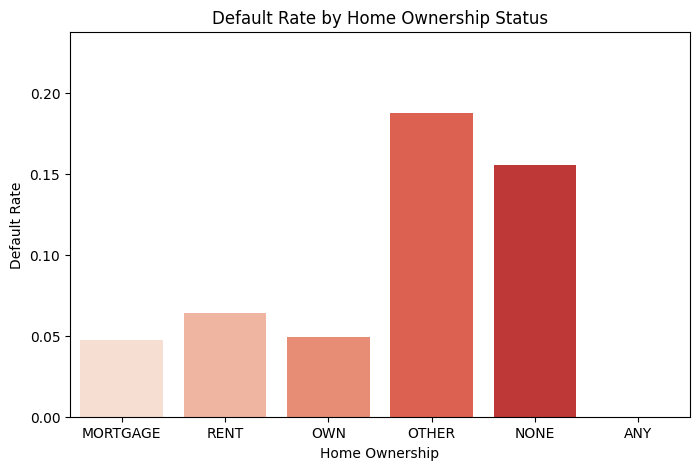

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate default rate by home ownership type
default_by_home = (
    df.groupBy("home_ownership")
      .agg(
          F.mean("default_ind").alias("default_rate"),
          F.count("*").alias("num_loans")
      )
)

# Convert to Pandas for plotting
default_home_pdf = default_by_home.toPandas()

# Step 2: Plot default rates
plt.figure(figsize=(8,5))
sns.barplot(x="home_ownership", y="default_rate", data=default_home_pdf, palette="Reds")
plt.title("Default Rate by Home Ownership Status")
plt.ylabel("Default Rate")
plt.xlabel("Home Ownership")
plt.ylim(0, default_home_pdf["default_rate"].max() + 0.05)
plt.show()


Analyze how loan age (credit age in years) affects default rates.

In [0]:
from pyspark.sql import functions as F

# Calculate min and max
credit_age_stats = df.agg(
    F.min("loan_age_years").alias("min_loan_age"),
    F.max("loan_age_years").alias("max_loan_age")
)

credit_age_stats.show()


+------------+------------+
|min_loan_age|max_loan_age|
+------------+------------+
|       10.72|       18.73|
+------------+------------+



/home/spark-d976d37c-01a4-4a9f-a87c-df/.ipykernel/2438/command-5995190149155417-1497138533:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Loan_age_bucket", y="default_rate", data=default_age_pdf, palette="Blues")


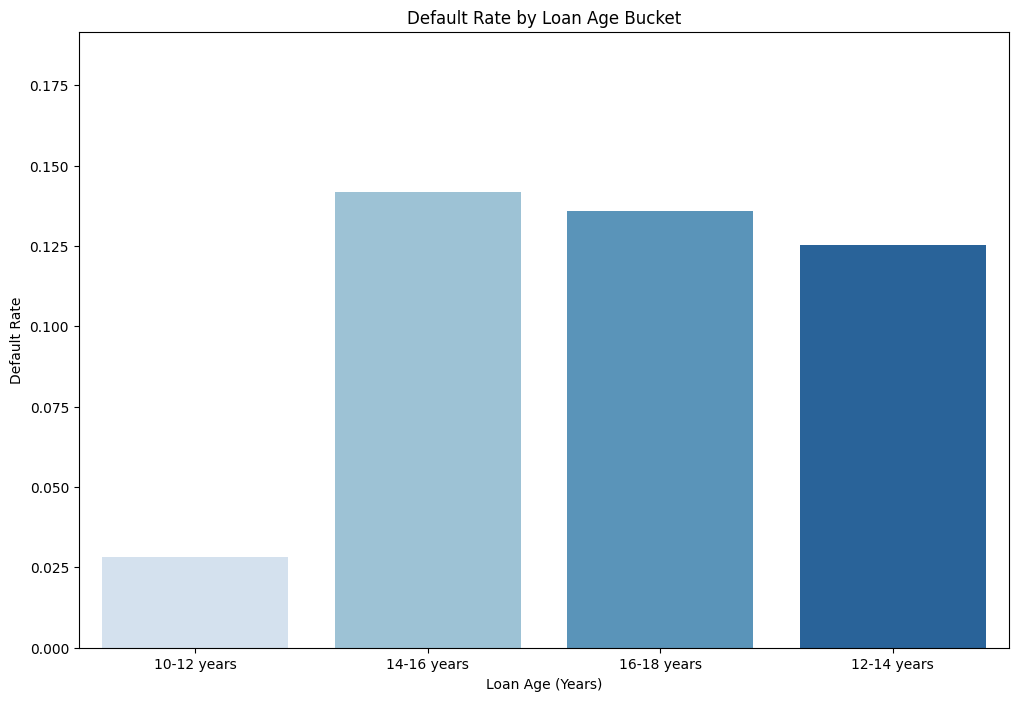

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Bucketize credit age (loan age in years)
df_buckets = df.withColumn(
    "Loan_age_bucket",
    F.when(F.col("loan_age_years") <12, "10-12 years")
     .when((F.col("loan_age_years") >= 12) & (F.col("loan_age_years") < 14), "12-14 years")
     .when((F.col("loan_age_years") >= 14) & (F.col("loan_age_years") < 16), "14-16 years")
     .otherwise("16-18 years")
)

# Step 2: Calculate default rate per bucket
default_by_age = (
    df_buckets.groupBy("Loan_age_bucket")
              .agg(
                  F.mean("default_ind").alias("default_rate"),
                  F.count("*").alias("num_loans")
              )
)

# Convert to Pandas for plotting
default_age_pdf = default_by_age.toPandas()

# Step 3: Plot default rate by credit age
plt.figure(figsize=(12,8))
sns.barplot(x="Loan_age_bucket", y="default_rate", data=default_age_pdf, palette="Blues")
plt.title("Default Rate by Loan Age Bucket")
plt.xlabel("Loan Age (Years)")
plt.ylabel("Default Rate")
plt.ylim(0, default_age_pdf["default_rate"].max() + 0.05)
plt.show()


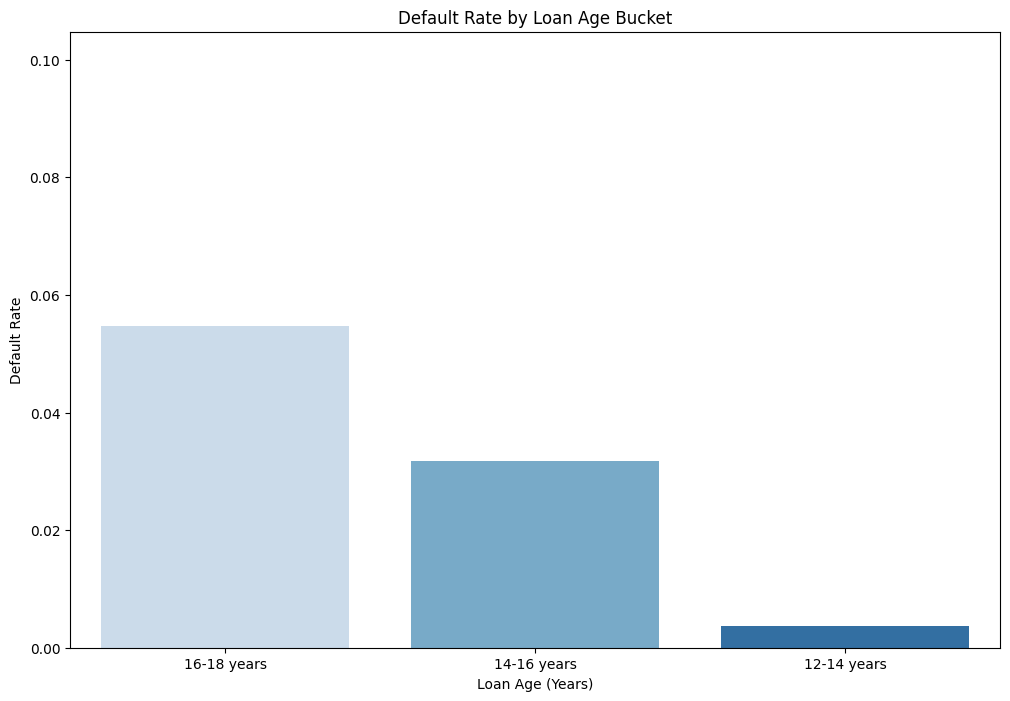

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Bucketize credit age (loan age in years)
df_buckets = df.withColumn(
    "Loan_age_bucket",
    F.when(F.col("credit_age_years") <12, "10-12 years")
     .when((F.col("credit_age_years") >= 12) & (F.col("credit_age_years") < 14), "12-14 years")
     .when((F.col("credit_age_years") >= 14) & (F.col("credit_age_years") < 16), "14-16 years")
     .otherwise("16-18 years")
)

# Step 2: Calculate default rate per bucket
default_by_age = (
    df_buckets.groupBy("Loan_age_bucket")
              .agg(
                  F.mean("default_ind").alias("default_rate"),
                  F.count("*").alias("num_loans")
              )
)

# Convert to Pandas for plotting
default_age_pdf = default_by_age.toPandas()

# Step 3: Plot default rate by credit age
plt.figure(figsize=(12,8))
sns.barplot(x="Loan_age_bucket", y="default_rate", data=default_age_pdf, palette="Blues")
plt.title("Default Rate by Loan Age Bucket")
plt.xlabel("Loan Age (Years)")
plt.ylabel("Default Rate")
plt.ylim(0, default_age_pdf["default_rate"].max() + 0.05)
plt.show()

Analyze the distribution of loan grades (grade) and visualize it to show that the majority of loans are B and C, which typically indicate medium-risk lending.

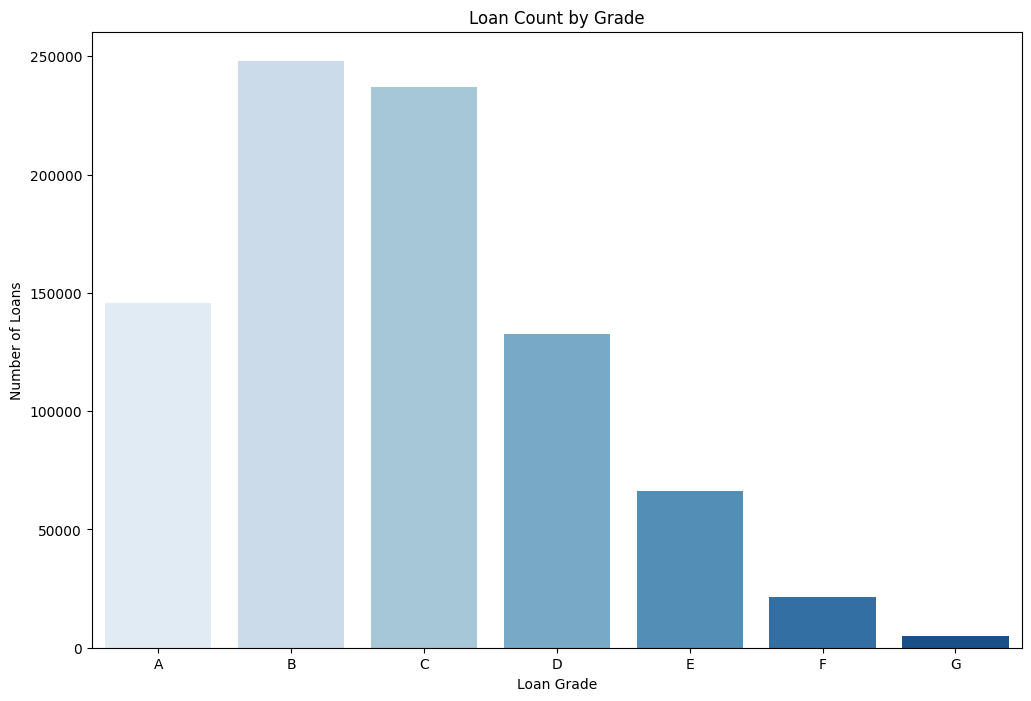

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate loan count by grade
loan_grade_counts = (
    df.groupBy("grade")
      .agg(F.count("*").alias("num_loans"))
      .orderBy("grade")
)

# Convert to Pandas for plotting
loan_grade_pdf = loan_grade_counts.toPandas()

# Step 2: Plot loan grade distribution
plt.figure(figsize=(12,8))
sns.barplot(x="grade", y="num_loans", data=loan_grade_pdf, palette="Blues")
plt.title("Loan Count by Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")
plt.show()


Interest rates vary significantly across loan grades and sub-grades

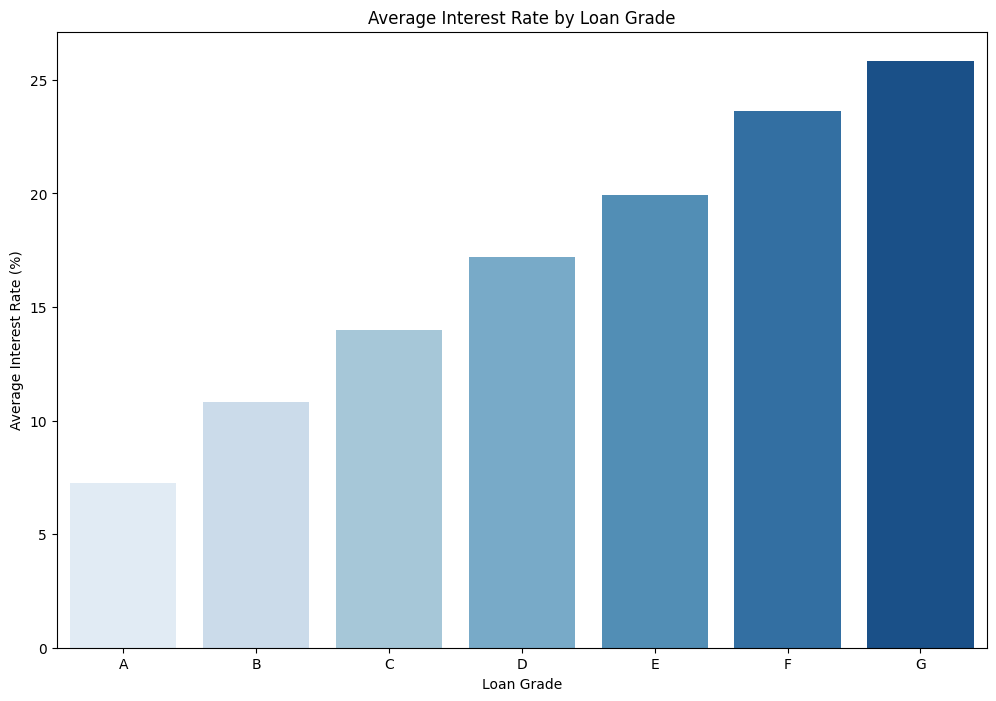

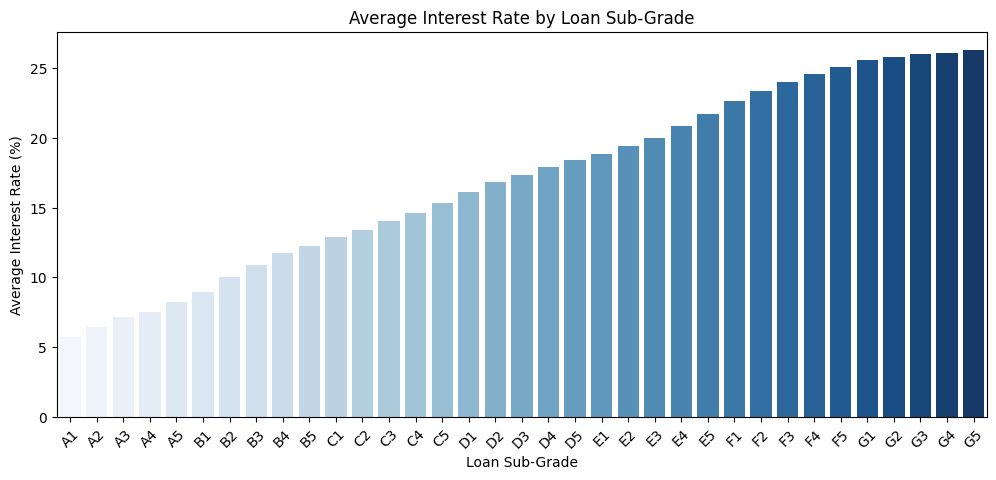

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert interest rate to numeric if needed
df = df.withColumn(
    "int_rate_numeric",
    F.regexp_replace(F.col("int_rate"), "%", "").cast("double")
)

# Step 2: Calculate average interest rate by grade
avg_int_by_grade = (
    df.groupBy("grade")
      .agg(F.mean("int_rate_numeric").alias("avg_int_rate"))
      .orderBy("grade")
)

avg_int_by_grade_pdf = avg_int_by_grade.toPandas()

# Step 3: Calculate average interest rate by sub_grade
avg_int_by_subgrade = (
    df.groupBy("sub_grade")
      .agg(F.mean("int_rate_numeric").alias("avg_int_rate"))
      .orderBy("sub_grade")
)

avg_int_by_subgrade_pdf = avg_int_by_subgrade.toPandas()

# Step 4: Plot interest rates by grade
plt.figure(figsize=(12,8))
sns.barplot(x="grade", y="avg_int_rate", data=avg_int_by_grade_pdf, palette="Blues")
plt.title("Average Interest Rate by Loan Grade")
plt.ylabel("Average Interest Rate (%)")
plt.xlabel("Loan Grade")
plt.show()

# Step 5: Plot interest rates by sub_grade
plt.figure(figsize=(12,5))
sns.barplot(x="sub_grade", y="avg_int_rate", data=avg_int_by_subgrade_pdf, palette="Blues")
plt.title("Average Interest Rate by Loan Sub-Grade")
plt.ylabel("Average Interest Rate (%)")
plt.xlabel("Loan Sub-Grade")
plt.xticks(rotation=45)
plt.show()


To demonstrate that recoveries are low relative to total defaults, we can calculate the total defaults, total recoveries, and their proportion

Total Defaults: 677164450.0
Total Recoveries: 40307151.705430545
Recovery Rate: 5.95%


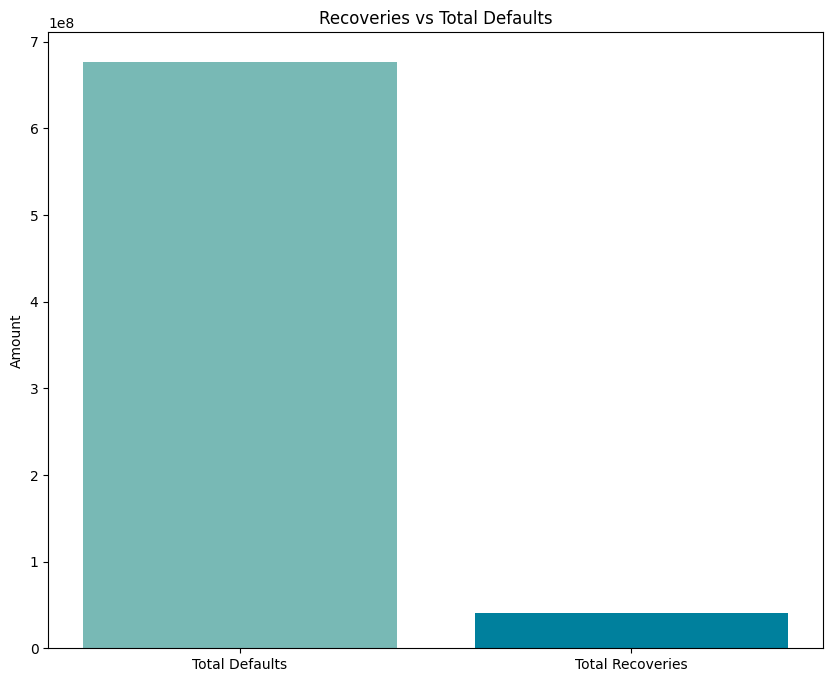

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Step 1: Ensure numeric columns
df = df.withColumn("recoveries_numeric", F.col("recoveries").cast("double"))
df = df.withColumn("total_pymnt_numeric", F.col("total_pymnt").cast("double"))
df = df.withColumn("loan_amnt_numeric", F.col("loan_amnt").cast("double"))
df = df.withColumn("default_ind_numeric", F.col("default_ind").cast("double"))

# Step 2: Calculate total defaults (total principal defaulted)
total_defaults = df.withColumn(
    "default_amount",
    F.col("loan_amnt_numeric") * F.col("default_ind_numeric")
).agg(F.sum("default_amount").alias("total_defaults")).collect()[0]["total_defaults"]

# Step 3: Calculate total recoveries
total_recoveries = df.agg(F.sum("recoveries_numeric").alias("total_recoveries")).collect()[0]["total_recoveries"]

# Step 4: Calculate recovery rate
recovery_rate = total_recoveries / total_defaults if total_defaults > 0 else 0
print(f"Total Defaults: {total_defaults}")
print(f"Total Recoveries: {total_recoveries}")
print(f"Recovery Rate: {recovery_rate:.2%}")

# Step 5: Plot comparison
plt.figure(figsize=(10,8))
plt.bar(["Total Defaults", "Total Recoveries"], [total_defaults, total_recoveries], color=["#78B9B5", "#00809D"])
plt.title("Recoveries vs Total Defaults")
plt.ylabel("Amount")
plt.show()
